# 기초통계 과제: DailyBox 마케팅 전략 분석 (템플릿)

`marketing_assignment_instructions.md`의 문항 번호에 맞춰 빈칸(`____`)을 채우고, 마크다운 셀에 해석/결론을 서술하세요. 여러분은 DailyBox 전략팀 분석가입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams['font.family'] = 'AppleGothic'   # Windows는 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

df = pd.read_csv('marketing_customers.csv')
df.head()

,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
0,1,21,Female,Organic Search,Basic,10,0.140,16.56,0.34,16.90,control,0,35.10
1,2,47,Female,Referral,Silver,7,0.037,7.45,8.00,15.45,treatment,0,55.42
2,3,42,Female,Social Ads,Silver,8,0.347,20.54,6.92,27.46,treatment,1,86.58
3,4,27,Female,Referral,Silver,5,0.269,9.98,2.80,12.78,control,0,20.63
4,5,26,Female,Social Ads,Basic,13,0.157,6.83,0.57,7.40,treatment,1,25.43


## Part 1. 고객 이해 (EDA)

**1. 데이터 로드 및 구조 확인**

In [5]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())   

(6000, 13)
customer_id            int64
age                    int64
gender                object
signup_channel        object
membership_tier       object
monthly_visits         int64
avg_discount_rate    float64
online_ad_cost       float64
offline_ad_cost      float64
total_ad_cost        float64
campaign_group        object
responded              int64
monthly_spend        float64
dtype: object
       customer_id          age  monthly_visits  avg_discount_rate  \
count  6000.000000  6000.000000     6000.000000        6000.000000   
mean   3000.500000    40.263333        8.201500           0.171374   
std    1732.195139    11.513402        4.221437           0.096024   
min       1.000000    18.000000        1.000000           0.000000   
25%    1500.750000    32.000000        5.000000           0.098000   
50%    3000.500000    40.000000        8.000000           0.158000   
75%    4500.250000    48.000000       11.000000           0.233250   
max    6000.000000    78.000000       

> ✍️ 고객 규모와 주요 수치 변수 범위를 한두 줄로 요약하세요.

: 데이터는 6,000명의 고객과 13개의 변수로 구성되어 있으며, 변수별 결측치는 모두 0개이다.  
고객 나이는 18~78세, 월 방문 횟수는 0~34회, 월 구매액은 3.40~288.44 범위이다.  
월 구매액의 평균은 약 32.27, 중앙값은 약 28.25로 평균이 중앙값보다 커 오른쪽 꼬리가 긴 분포일 가능성이 보인다.

**2. 매출 분포와 로그변환** — monthly_spend 왜도 계산 + log1p 전/후 비교

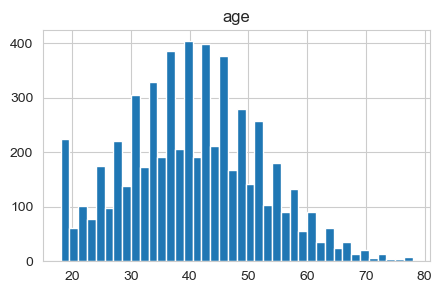

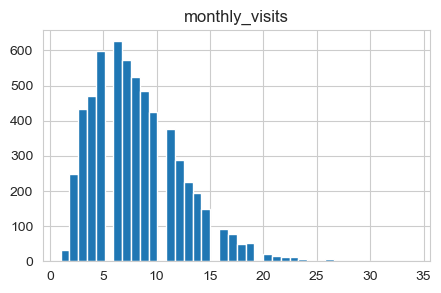

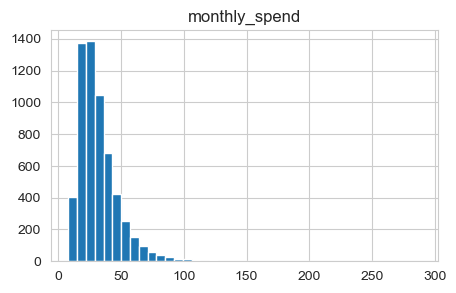

왜도 = 2.5456526289788064


C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


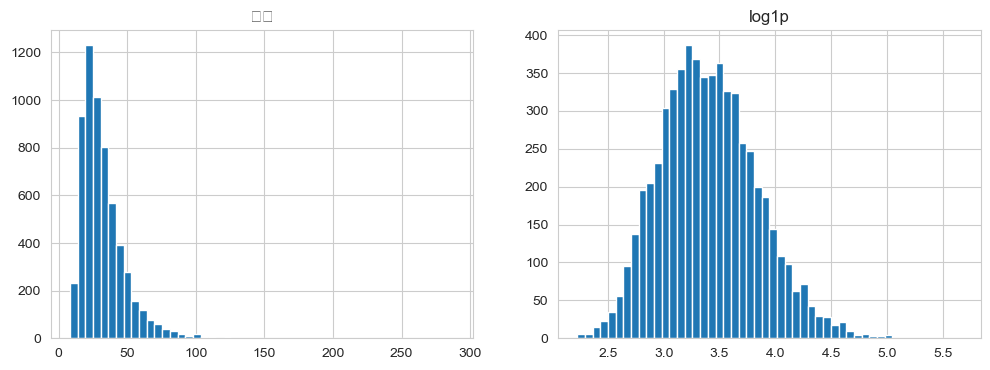

In [6]:
for col in ['age', 'monthly_visits', 'monthly_spend']:
    plt.figure(figsize=(5, 3))
    plt.hist(df[col], bins=40)
    plt.title(col); plt.show()

skew = df['monthly_spend'].skew()   # 힌트: 왜도 메서드
print('왜도 =', skew)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_spend'], bins=50);          axes[0].set_title('원본')
axes[1].hist(np.log1p(df['monthly_spend']), bins=50)  
axes[1].set_title('log1p'); plt.show()

> ✍️ 매출 분포가 왜 치우쳐 있는지, 로그변환이 왜 도움이 되는지 서술하세요.

: `monthly_spend`의 왜도는 2.546으로 강한 양의 왜도를 보인다.  
대부분의 고객은 비교적 낮거나 중간 수준의 구매액을 보이지만, 일부 고가치 고객의 매우 큰 구매액이 오른쪽 꼬리를 길게 만들고 평균을 끌어올린다.  
`log1p` 변환 후 왜도는 0.384로 크게 감소한다. 로그변환은 큰 값의 영향력을 압축하여 분포를 대칭에 가깝게 만들고,  
극단값의 영향 및 이분산성을 줄여 통계 검정과 회귀모형의 가정을 개선하는 데 도움이 된다.

**3. 채널·등급별 매출 Boxplot**

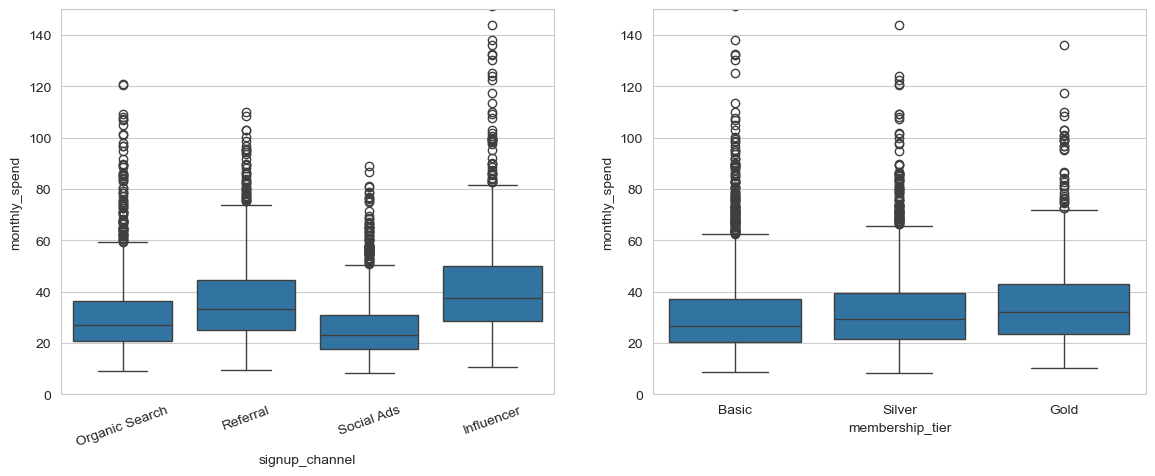

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='signup_channel', y='monthly_spend', ax=axes[0])
axes[0].set_ylim(0, 150); axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='membership_tier', y='monthly_spend',    # 힌트: 'membership_tier'
            order=['Basic', 'Silver', 'Gold'], ax=axes[1])
axes[1].set_ylim(0, 150); plt.show()

> ✍️ 어떤 채널/등급이 고가치 고객으로 보이는지 해석하세요.

: 채널별 평균 구매액은 Influencer(42.87) > Referral(36.69) > Organic Search(30.51) > Social Ads(25.85) 순이다.  
따라서 Influencer 채널이 가장 높은 가치의 고객을 유입시키고, Social Ads는 상대적으로 낮은 가치의 고객을 유입시키는 것으로 보인다.  
멤버십별로는 Gold(36.48) > Silver(32.86) > Basic(30.90) 순으로, 등급이 높을수록 월 구매액의 중심과 상단 범위가 높아지는 경향이 있다.

## Part 2. 가정 확인

**4. 1종/2종 오류 (개념)**

> ✍️ "쿠폰 캠페인은 효과가 없다"는 H0에 대해 1종 오류와 2종 오류가 각각 무엇을 의미하고, 어떤 손실을 끼치는지 서술하세요.

: 귀무가설 H0 - “쿠폰 캠페인은 매출에 효과가 없다.”  
-1종 오류는 실제로 캠페인 효과가 없는데도 효과가 있다고 판단하는 것이다. 이 경우 다음 분기에도 쿠폰 비용과 운영비를 투입하게 되어 예산 낭비가 발생한다.  
-2종 오류는 실제로 캠페인 효과가 있는데도 효과가 없다고 판단하는 것이다. 이 경우 효과적인 캠페인을 중단하여 추가 매출과 고객 전환을 얻지 못하는 기회 손실이 발생한다.

**5. 정규성 검정 (Shapiro-Wilk) — 원본 vs 로그**

C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


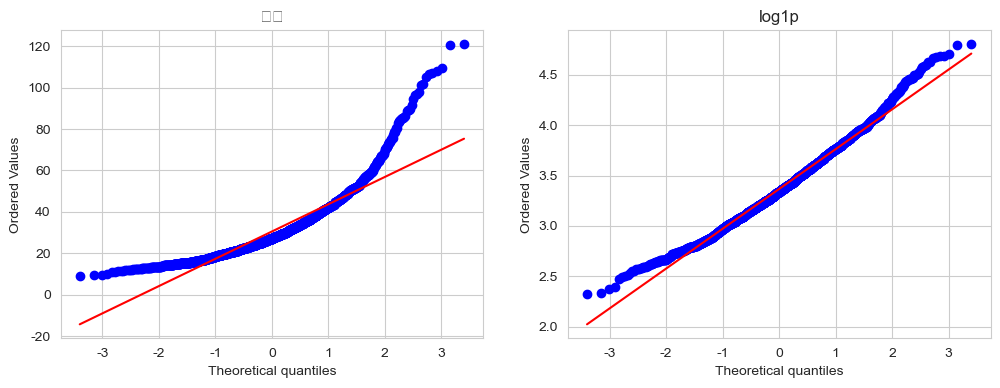

원본   ShapiroResult(statistic=np.float64(0.8534533976380867), pvalue=np.float64(3.631642400263992e-21))
log1p  ShapiroResult(statistic=np.float64(0.9873230180962407), pvalue=np.float64(0.00024486116128267225))


In [9]:
x = df.loc[df.signup_channel == 'Organic Search', 'monthly_spend']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(x, dist='norm', plot=axes[0]);            axes[0].set_title('원본')
stats.probplot(np.log1p(x), dist='norm', plot=axes[1]);  axes[1].set_title('log1p')
plt.show()

xs = x.sample(500, random_state=0)
print('원본  ', stats.shapiro(xs))          # 힌트: shapiro
print('log1p ', stats.shapiro(np.log1p(xs)))

> ✍️ 가설을 세우고, 두 결과를 0.05 기준으로 비교 해석하세요.

: H0: Organic Search 고객의 `monthly_spend`는 정규분포를 따른다. H1: 정규분포를 따르지 않는다.  
원본의 Shapiro-Wilk p-value는 3.63×10⁻²¹로 0.05보다 작아 H0를 기각한다.  
로그변환 후 p-value도 0.000245로 0.05보다 작아 엄밀한 정규성은 여전히 기각된다.  
다만 Q-Q plot과 검정통계량이 0.853에서 0.987로 개선되어 로그변환 후 분포가 정규분포에 훨씬 가까워졌다.  
과제 지시에 따라 이후 분석에서는 정규성을 만족한다고 가정한다.

**6. 등분산성 검정**

In [10]:
groups = [g['monthly_spend'].values for _, g in df.groupby('signup_channel')]
stat, p = stats.levene(*groups) 
print('Levene p =', p)

Levene p = 4.335927248200273e-44


> ✍️ p값을 0.05 기준으로 해석하고, ANOVA에 어떤 의미인지 서술하세요.

: H0는 네 채널의 분산이 동일하다는 것이다. Levene 검정 p-value는 4.34×10⁻⁴⁴로 0.05보다 작으므로 등분산 가정을 기각한다.  
즉 채널별 구매액의 변동성이 서로 다르다. 고전적 One-way ANOVA의 등분산 가정이 위배되므로 결과 해석에 주의가 필요하며,  
실무적으로는 Welch ANOVA나 강건한 방법을 추가로 검토할 수 있다. 본 과제에서는 명세에 따라 일반 ANOVA를 수행한다.

## Part 3. 집단 비교 검정

**7. 쿠폰 캠페인 효과 검증 — 두 집단 평균 비교 (Welch's t-test)**

In [11]:
ctrl = df.loc[df.campaign_group == 'control', 'monthly_spend']
trt  = df.loc[df.campaign_group == 'treatment', 'monthly_spend']  
print('평균', ctrl.mean(), trt.mean())

print('Levene p =', stats.levene(ctrl, trt).pvalue)
# 등분산이 깨지면 equal_var=False (Welch)
t, p = stats.ttest_ind(ctrl, trt, equal_var=False)         
print('t=%.2f p=%.3g' % (t, p))

평균 29.707517635203224 34.80327820046312
Levene p = 1.164492092129461e-19
t=-11.88 p=3.86e-32


> ✍️ H0/H1을 명시하고, 캠페인을 지속할지 결론 내리세요.

: H0: treatment와 control의 평균 월 구매액은 같다. H1: 두 집단의 평균 월 구매액은 다르다.  
Levene p-value가 1.16×10⁻¹⁹로 등분산 가정이 깨졌으므로 Welch's t-test를 사용했다.  
검정 결과 p-value는 3.86×10⁻³²로 0.05보다 작아 H0를 기각한다.  
treatment 평균은 34.80, control 평균은 29.71로 쿠폰 발송군이 약 5.10(17.2%) 높다.  
무작위 배정 실험이라는 점을 고려하면 쿠폰 캠페인이 매출을 높인 근거가 있으므로 다음 분기에도 지속하되, 채널별 효과 차이를 반영해 타겟팅하는 것이 적절하다.

**8. 채널 비교 — One-way ANOVA + Tukey HSD**

In [12]:
F, p = stats.f_oneway(*groups)
print('ANOVA F=%.2f p=%.3g' % (F, p))

tukey = pairwise_tukeyhsd(df['monthly_spend'], df['signup_channel'], alpha=0.05)  
print(tukey)

ANOVA F=276.85 p=2.67e-168
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
    Influencer Organic Search -12.3582   0.0 -13.9696 -10.7469   True
    Influencer       Referral  -6.1796   0.0  -7.9507  -4.4086   True
    Influencer     Social Ads -17.0177   0.0 -18.6659 -15.3696   True
Organic Search       Referral   6.1786   0.0    4.716   7.6412   True
Organic Search     Social Ads  -4.6595   0.0  -5.9706  -3.3484   True
      Referral     Social Ads -10.8381   0.0 -12.3412   -9.335   True
---------------------------------------------------------------------


> ✍️ 가설을 세우고, 어느 채널이 유의하게 고가치/저가치인지 결론지으세요.

: H0: 네 유입 채널의 평균 월 구매액은 모두 같다. H1: 적어도 한 채널의 평균은 다르다.  
ANOVA p-value는 2.67×10⁻¹⁶⁸로 H0를 기각한다. Tukey HSD 결과 여섯 개 채널 쌍이 모두 유의하게 달랐다.  
평균 순위는 Influencer > Referral > Organic Search > Social Ads이며, Influencer는 모든 다른 채널보다 유의하게 높고 Social Ads는 모든 다른 채널보다 유의하게 낮다.  
따라서 고가치 고객 확보에는 Influencer와 Referral이 유리하고, Social Ads는 예산 효율을 재검토해야 한다.

**9. 교호작용 — Two-way ANOVA (선택 심화)**

In [13]:
model = smf.ols('monthly_spend ~ C(signup_channel) * C(campaign_group)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

                                           sum_sq      df           F  \
C(signup_channel)                    2.069851e+05     3.0  284.971525   
C(campaign_group)                    3.868639e+04     1.0  159.787112   
C(signup_channel):C(campaign_group)  6.749231e+03     3.0    9.292159   
Residual                             1.450735e+06  5992.0         NaN   

                                            PR(>F)  
C(signup_channel)                    6.336934e-173  
C(campaign_group)                     3.634363e-36  
C(signup_channel):C(campaign_group)   3.973329e-06  
Residual                                       NaN  


> ✍️ 각 주효과와 교호작용의 유의성을 해석하세요.

: Two-way ANOVA 결과 유입 채널 주효과(p≈6.34×10⁻¹⁷³), 캠페인 주효과(p≈3.63×10⁻³⁶), 채널×캠페인 교호작용(p≈3.97×10⁻⁶)이 모두 유의하다.  
즉 채널에 따라 기본 매출 수준이 다르고, 쿠폰 발송 여부도 매출에 영향을 주며, 쿠폰 효과의 크기는 채널마다 동일하지 않다.  
따라서 모든 채널에 동일하게 쿠폰을 배포하기보다 채널별 증분 효과를 확인해 차등 운영하는 것이 타당하다.

## Part 4. 회귀분석

**10. 단순선형회귀 & 다중회귀**

In [14]:
# 단순
m1 = smf.ols('monthly_spend ~ monthly_visits', data=df).fit()   
print(m1.summary().tables[1]); print('R2 =', m1.rsquared)

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.6737      0.462     53.357      0.000      23.767      25.580
monthly_visits     0.9268      0.050     18.487      0.000       0.829       1.025
R2 = 0.053909275630528386


In [15]:
# 다중 (범주형은 C()로 더미코딩)
m2 = smf.ols(
    'monthly_spend ~ monthly_visits + avg_discount_rate + online_ad_cost '
    '+ C(signup_channel) + C(gender)', data=df).fit()     #
print(m2.summary())
print('단순 adjR2=%.4f / 다중 adjR2=%.4f' % (m1.rsquared_adj, m2.rsquared_adj))

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     238.3
Date:                Thu, 16 Jul 2026   Prob (F-statistic):          9.35e-314
Time:                        21:09:14   Log-Likelihood:                -24723.
No. Observations:                6000   AIC:                         4.946e+04
Df Residuals:                    5992   BIC:                         4.952e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

> ✍️ 방문·할인·광고비 중 매출에 실제로 기여하는 레버는? 할인 확대는 좋은 전략인가? 채널 계수는 어떻게 해석되나?

: 단순회귀에서 월 방문 1회 증가는 평균 구매액 **0.927 증가**와 연관되며, R²는 **0.0539**이다. 방문 횟수만으로는 매출 변동의 약 5.4%만 설명한다.  
다중회귀의 Adjusted R²는 0.2168로 단순회귀보다 높다. 다른 조건을 통제할 때 월 방문 1회 증가는 구매액 0.917 증가,  
온라인 광고비 1단위 증가는 0.368 증가와 연관되며 둘 다 유의하다. 할인율 계수는 11.423이므로 할인율이 0.10(10%p) 높아질 때 구매액은 약 1.142 증가와 연관되지만,  
할인 확대는 매출액을 조금 높이더라도 마진을 낮출 수 있으므로 매출 계수만으로 무조건 확대해서는 안 된다.  
기준 채널은 Influencer이다. 다른 조건이 같을 때 Organic Search는 약 12.19, Referral은 5.86, Social Ads는 16.70 낮다.  
따라서 매출 관점의 우선 레버는 고객 방문 활성화와 고가치 채널 유입이며, 광고비는 추가 매출뿐 아니라 획득비용 대비 수익성(ROAS)을 함께 평가해야 한다.  
남성 계수는 -2.73으로 여성 대비 낮은 구매액과 연관되지만, 이는 관찰적 연관성이며 차별적 타겟팅의 단독 근거로 사용해서는 안 된다.

**11. 다중공선성 / VIF** — online + offline + total 모두 넣기

In [16]:
def vif_table(X):
    X = sm.add_constant(X)
    return pd.DataFrame({'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})

X_bad = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost', 'total_ad_cost']] 
print(vif_table(X_bad))

X_ok = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost']]  # total 제거
print(vif_table(X_ok))

           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost       inf
3  offline_ad_cost       inf
4    total_ad_cost       inf
           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost  1.000251
3  offline_ad_cost  1.000213


c:\Users\pc\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


> ✍️ VIF에 어떤 문제가 있고 왜 그런지(total=online+offline), 어떻게 해결하는지 서술하세요.

: `online_ad_cost`, `offline_ad_cost`, `total_ad_cost`를 동시에 넣으면 세 광고비 변수의 VIF가 무한대이다.  
`total_ad_cost = online_ad_cost + offline_ad_cost`라는 완전한 선형관계가 있어 한 변수가 나머지 두 변수로 정확히 설명되기 때문이다.  
`total_ad_cost`를 제거하면 online과 offline의 VIF는 각각 약 1.000으로 정상화된다.  
해결책은 총액과 세부 항목을 동시에 사용하지 않고, 분석 목적에 따라 총액 하나 또는 online/offline 두 항목 중 하나의 표현만 선택하는 것이다.

**12. 잔차 진단** (+ 로그변환 비교)

C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing fro

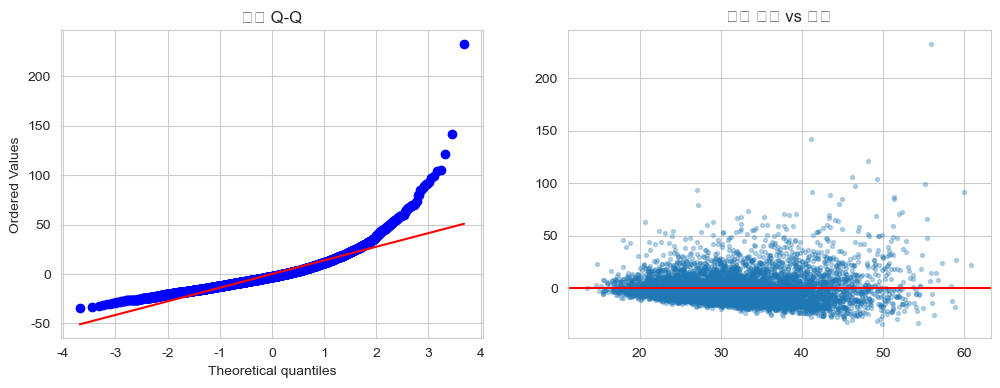

C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


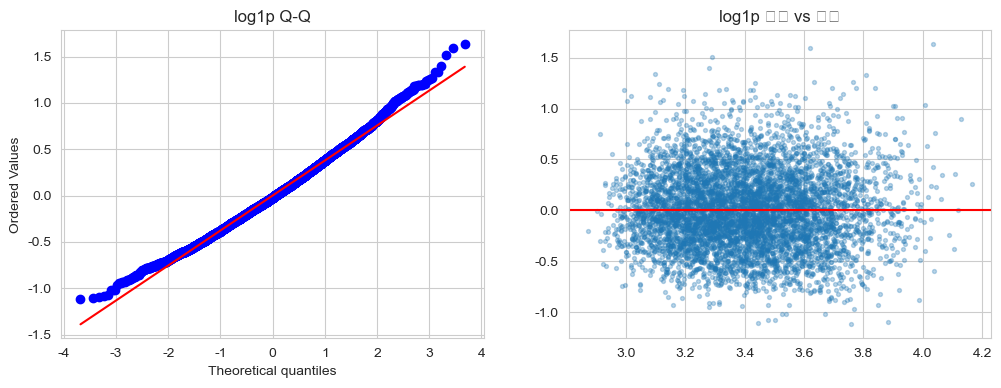

In [17]:
def resid_plots(model, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    stats.probplot(model.resid, dist='norm', plot=axes[0]); axes[0].set_title(title+' Q-Q')
    axes[1].scatter(model.fittedvalues, model.resid, s=8, alpha=0.3)
    axes[1].axhline(0, color='red'); axes[1].set_title(title+' 잔차 vs 예측')
    plt.show()

resid_plots(m2, '원본')

m2_log = smf.ols('np.log1p(monthly_spend) ~ monthly_visits + avg_discount_rate '
                 '+ online_ad_cost + C(signup_channel) + C(gender)', data=df).fit()
resid_plots(m2_log, 'log1p')

> ✍️ 원본 대비 로그변환 모형의 잔차가 어떻게 개선되는지 서술하세요.

: 원본 모형의 Q-Q plot은 상단 꼬리에서 직선으로부터 크게 벗어나며, 잔차-예측값 그래프에서도 예측값이 커질수록 잔차의 산포가 커지는 형태가 나타난다.  
이는 잔차의 비정규성과 이분산성을 시사한다. `log1p(monthly_spend)` 모형에서는 Q-Q plot이 직선에 더 가까워지고 잔차 산포도 상대적으로 균일해져 가정이 개선된다.  
다만 시각적으로 완전히 이상적인 형태는 아니므로 강건 표준오차나 추가 변수·비선형항 검토가 가능하다.

## Part 5. 타겟팅 (로지스틱 회귀)

**13~14. 로지스틱 회귀 & 오즈비 해석**

In [18]:
logit = smf.logit(
    'responded ~ age + monthly_visits + C(campaign_group) + C(membership_tier) '
    '+ C(signup_channel)', data=df).fit()
print(logit.summary())

odds = pd.DataFrame({'coef': logit.params, 'p': logit.pvalues,
                     'odds_ratio': np.exp(logit.params)})  
print(odds.round(3))

Optimization terminated successfully.
         Current function value: 0.512887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              responded   No. Observations:                 6000
Model:                          Logit   Df Residuals:                     5991
Method:                           MLE   Df Model:                            8
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                 0.06405
Time:                        21:20:40   Log-Likelihood:                -3077.3
converged:                       True   LL-Null:                       -3287.9
Covariance Type:            nonrobust   LLR p-value:                 5.453e-86
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.2301      0.157 

> ✍️ 쿠폰 발송·멤버십 등급의 오즈비를 해석하고, 다음 캠페인 타겟 세그먼트를 정하세요.

: 다른 변수를 통제했을 때 쿠폰 발송군의 오즈비는 2.434로, 미발송군보다 반응 오즈가 약 2.43배 높다.  
멤버십 기준은 Basic이며, Gold의 오즈비는 2.019, Silver는 1.407로 모두 유의하다. 즉 등급이 높은 고객일수록 반응 가능성이 높다.  
채널 기준은 Influencer이며, Organic Search(0.535), Referral(0.586), Social Ads(0.515)는 Influencer보다 반응 오즈가 낮다.  
월 방문 횟수의 오즈비는 1.041로 1회 증가할 때 반응 오즈가 약 4.1% 증가한다.  
따라서 다음 캠페인은 Gold·Silver 멤버십, 방문 빈도가 높은 고객, 특히 Influencer 유입 고객을 우선 대상으로 삼는 것이 합리적이다.  
다만 캠페인의 목적이 신규 고객 확대라면 고반응군만 집중할 때 도달 범위가 축소될 수 있으므로 일부 탐색 예산은 다른 세그먼트에 유지해야 한다.


## 종합 결론 — CMO 보고용 마케팅 전략

> ✍️ Part 1~5를 종합해 (1) 캠페인 지속 여부 (2) 채널 예산 배분 (3) 매출 레버 (4) 타겟팅 (5) 분석 한계를 담은 한 장짜리 전략을 서술하세요. (report.pdf의 핵심)